# Lab 2: Data Preprocessing

## Các nội dung chính
1. Mục tiêu:
*   Nắm được các bước cơ bản trong khâu tiền xử lí dữ liệu.


2. Dữ liệu:
* Dữ liệu bất động sản - *Bengaluru_House_Data*
> Gồm các trường dữ liệu: location, size, total_sqft, price, ...


> Link Kaggle: https://www.kaggle.com/amitabhajoy/bengaluru-house-price-data




3. Yêu cầu:
* Sử dụng các công cụ (Pandas, Seaborn, ...) để thực hiện xem xét, đánh giá đặc điểm của dữ liệu, từ đó đưa ra phương án tiền xử lí dữ liệu (làm sạch, trích xuất thông tin ban đầu, ...)




## Nội dung thực hành

### 1. Chuẩn bị các thư viện cần thiết

In [1]:
import numpy as np #Làm việc với các dữ liệu mảng nhiều chiều
import pandas as pd #Giúp làm việc với các dữ liệu dạng bảng
import matplotlib.pyplot as plt #Thư viện hỗ trợ trực quan hóa dữ liệu
import seaborn as sns #Thư viện giúp trực quan hóa dữ liệu, được xây trên matplotlib

### 2. Load dữ liệu từ file đã tải về

2.1. Đọc dữ liệu bằng pandas, dạng dataframe

In [2]:
path = "D:/DATA/VINHUNI/GIẢNG DẠY/2025_2026_2/Khai phá dữ liệu/Labs/Lab 2-Data Preprocessing/Bengaluru_House_Data.csv"
df_raw = pd.read_csv(path)
df_raw.shape

(13320, 9)

2.2. Xem 5 mẫu đầu tiên

In [3]:
df_raw.head() # return DataFrame

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


2.3. Xem 5 mẫu cuối cùng

In [4]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


### 3. Phân tích dữ liệu thăm dò (Exploratory Data Analysis-EDA)

In [5]:
df = df_raw.copy() #Tạo bản sao để thực hiện EDA

3.1. Thông tin cơ bản về dữ liệu: tên, số giá trị non-null, kiểu dữ liệu của từng trường

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


3.2. Thống kê một số thuộc tính cơ bản của dữ liệu: count, mean, std, min, max, quartile

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


3.3. Thống kê các giá trị duy nhất của từng trường và số lần xuất hiện của chúng

In [8]:
def value_count(df):
  for var in df.columns:
    print(df[var].value_counts().to_string())
    print("--------------------------------")
value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
--------------------------------
availability
Ready To Move           10581
18-Dec                    307
18-May                    295
18-Apr                    271
18-Aug                    200
19-Dec                    185
18-Jul                    143
18-Mar                    131
18-Jun                     99
20-Dec                     98
21-Dec                     93
19-Mar                     88
18-Feb                     62
18-Nov                     47
18-Jan                     43
18-Sep                     41
19-Jun                     40
18-Oct                     39
19-Jan                     39
19-Jul                     36
17-Dec                     29
20-Jan                     24
17-Oct                     21
19-Sep                     21
22-Jun                     19
19-Aug                     18
21-Jun                     17
19-Apr            

3.4. Xem xét tương quan về giá trị của các cặp trường số

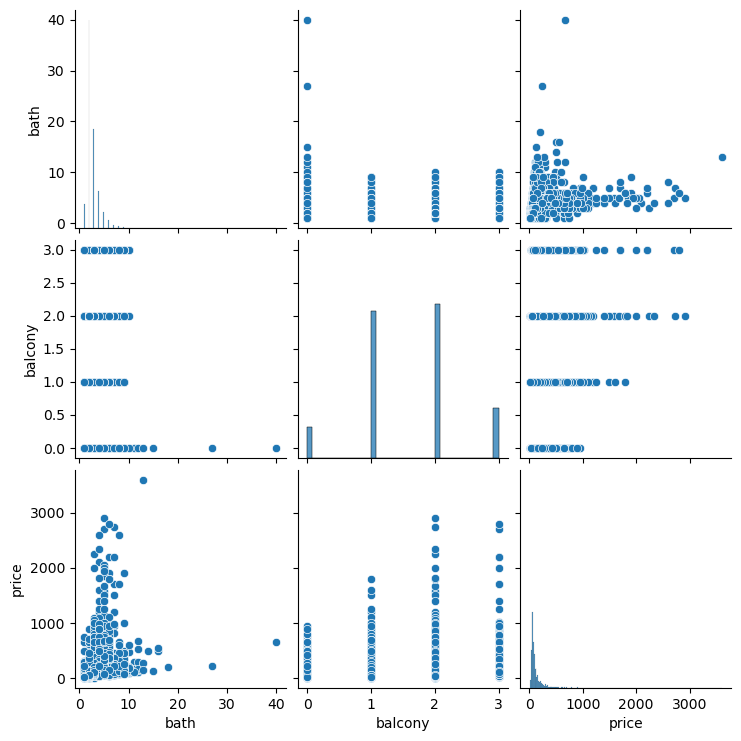

In [9]:
sns.pairplot(df)

<Axes: >

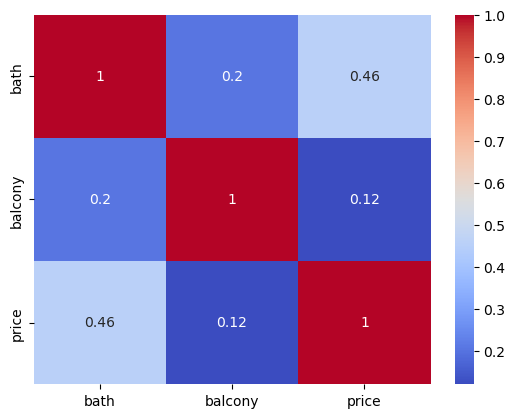

In [10]:
num_vars = ["bath", "balcony", "price"]
sns.heatmap(df[num_vars].corr(),cmap="coolwarm", annot=True)

### 4. Tiền xử lý dữ liệu

#### 4.1. Data Cleaning & Data Transformation

##### 4.1.1. Xử lí các giá trị Null/ NaN

1. Thống kê tỉ lệ giá trị null của từng thuộc tính

In [11]:
df.isnull().mean()*100  # Tỷ lệ giá trị null của từng thuộc tính

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

2. Loại đi trường society vì tỉ lệ null cao (41%)

In [12]:
df2 = df.drop('society', axis='columns')
df2.shape

(13320, 8)

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   total_sqft    13320 non-null  object 
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(3), object(5)
memory usage: 832.6+ KB


3. Thay thế giá trị null trong trường balcony bằng giá trị trung bình của các giá trị non-null

In [14]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

4. Xóa đi các mẫu dữ liệu (hàng) có giá trị NaN (không có giá trị)

In [15]:
df3 = df2.dropna()
df3.shape

(13246, 8)

In [16]:
df3.isnull().sum() #Thống kê lại xem đã xử lí hết các dữ liệu null hay chưa?

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

##### 4.1.2. Xử lí các trường thuộc tính

In [16]:
# Xem toàn bộ giá trị có thể có của dữ liệu
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

1. Chuyển thuộc tính 'total_sqft' sang kiểu dữ liệu numeric (float)

In [17]:
# Xem xét trường total_sqft
df3['total_sqft'].value_counts()

total_sqft
1200                 843
1100                 221
1500                 204
2400                 195
600                  180
1000                 172
1350                 132
1050                 123
1300                 117
1250                 114
900                  112
1400                 108
1800                 104
1150                 101
1600                 100
1140                  91
2000                  82
1450                  70
1650                  69
800                   67
3000                  66
1075                  66
1020                  63
2500                  62
1125                  60
1160                  60
1550                  60
950                   59
1700                  58
1180                  58
1260                  57
1255                  56
1080                  55
1220                  55
1070                  53
750                   52
700                   52
4000                  48
1175                  48
1225          

In [19]:
# Xử lí các giá trị của trường total_sqft và lưu vào một biến tạm
total_sqft_float = []
for str_val in df3['total_sqft']:
  try:
    total_sqft_float.append(float(str_val))
  except:
    try:
      temp = []
      temp = str_val.split('-')
      total_sqft_float.append((float(temp[0])+float(temp[-1]))/2)
    except:
      total_sqft_float.append(np.nan)
df4 = df3.reset_index(drop=True)

In [20]:
# Thêm trường total_sqft_float
df5 = df4.join(pd.DataFrame({'total_sqft_float':total_sqft_float}))
df5.head() #Quan sát kết quả sau khi xử lí

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [21]:
# Xóa cột "total_sqft"
df5 = df5.drop('total_sqft', axis='columns')
df5.shape

(13246, 8)

In [22]:
# Xem xét lại thông tin về các giá trị null
df5.isnull().sum()

area_type            0
availability         0
location             0
size                 0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [23]:
# Loại bỏ các hàng có giá trị null
df6 = df5.dropna()
df6.shape

(13200, 8)

In [24]:
# Xem lại thông tin của dataframe
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  object 
 1   availability      13200 non-null  object 
 2   location          13200 non-null  object 
 3   size              13200 non-null  object 
 4   bath              13200 non-null  float64
 5   balcony           13200 non-null  float64
 6   price             13200 non-null  float64
 7   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(4)
memory usage: 928.1+ KB


2. Làm việc với feature: *size*

In [26]:
# Quan sát sự phân bố giá trị của trường 'size' với value_counts
df6['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
7 Bedroom       83
8 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [27]:
# Chuyển thuộc tính số phòng từ dạng category về dạng numeric
size_int = []
for str_val in df6['size']:
  temp=[]
  temp = str_val.split(" ")
  try:
    size_int.append(int(temp[0]))
  except:
    size_int.append(np.nan)
    print("Noise = ", str_val)

In [28]:
# Đánh lại index cho các hàng
df6 = df6.reset_index(drop=True)

In [29]:
# Thêm trường dữ liệu số phòng (bhk)
df7 = df6.join(pd.DataFrame({'bhk':size_int}))
df7.shape

(13200, 9)

In [30]:
# In ra kết quả thực hiện các thao tác kể trên?
df7.tail()

,area_type,availability,location,size,bath,balcony,price,total_sqft_float,bhk
13195,Built-up Area,Ready To Move,Whitefield,5 Bedroom,4.0,0.000000,231.0,3453.0,5
13196,Super built-up Area,Ready To Move,Richards Town,4 BHK,5.0,1.584376,400.0,3600.0,4
13197,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,2.0,1.000000,60.0,1141.0,2
13198,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4.0,1.000000,488.0,4689.0,4
13199,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,1.0,1.000000,17.0,550.0,1


##### 4.1.3. Phát hiện ngoại lệ (outlier) và loại bỏ
* Dựa trên biểu đồ boxplot/ hoặc công cụ khác để phát hiện và loại bỏ các điểm ngoại lai:

<Axes: xlabel='total_sqft_float'>

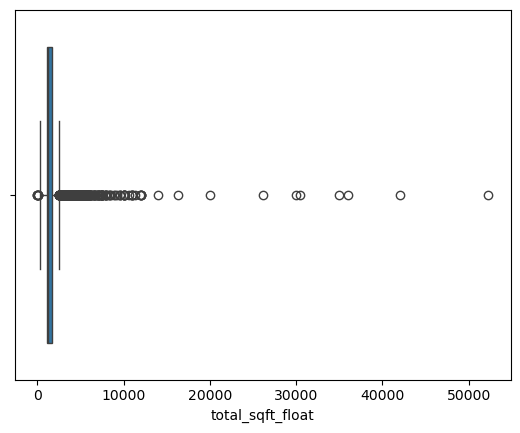

In [31]:
# Xem xét trường diện tích:
sns.boxplot(x = df7['total_sqft_float'])

<Axes: xlabel='total_sqft_float'>

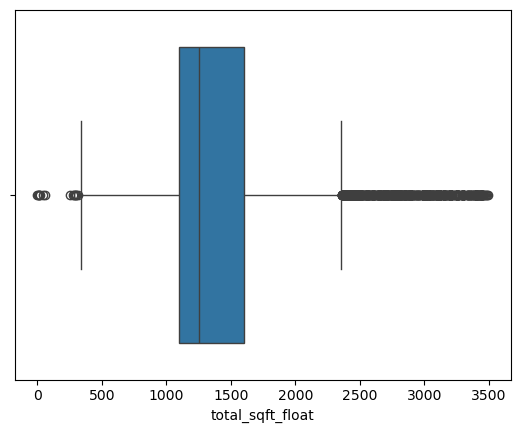

In [32]:
# Chọn ngưỡng diện tích là 3500 để xem xét
df_temp7 = df7[df7['total_sqft_float'] < 3500]
sns.boxplot(x = df_temp7['total_sqft_float'])

In [33]:
Q1 = df7['total_sqft_float'].quantile(0.25)
Q3 = df7['total_sqft_float'].quantile(0.75)
IQR = Q3 - Q1
low_threshold = Q1 - 1.5*IQR
up_threshold = Q3 + 1.5*IQR
print(low_threshold, up_threshold)

242.0 2530.0


(11128, 9)

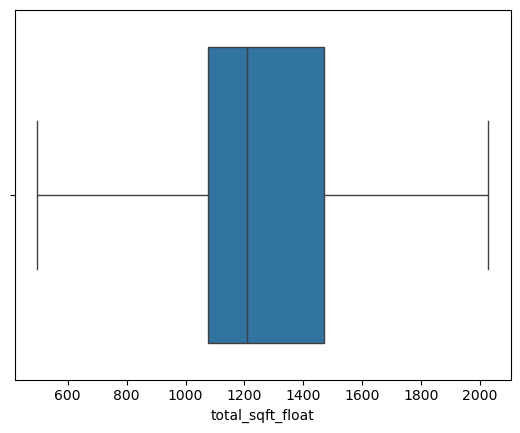

In [ ]:
# Loại bỏ đi các điểm dữ liệu có diện tích nhiễu
# (Q1 - 1.5 * IQR or Q3 + 1.5 * IQR)
df8 = df7[(df7['total_sqft_float'] >= low_threshold+250) & (df7['total_sqft_float'] <= up_threshold-500)]
sns.boxplot(x = df8['total_sqft_float'])
df8.shape

In [ ]:
# Tạo thêm trường dữ liệu price_per_sqft (giá/ diện tích feet vuông)
df8 = df8.reset_index(drop=True)
df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']
df8.head()

,area_type,availability,location,size,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0,2,3699.810606
1,Built-up Area,Ready To Move,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0,3,4305.555556
2,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0,3,6245.890861
3,Super built-up Area,Ready To Move,Kothanur,2 BHK,2.0,1.0,51.00,1200.0,2,4250.000000
4,Super built-up Area,Ready To Move,Whitefield,2 BHK,2.0,1.0,38.00,1170.0,2,3247.863248


In [38]:
df8.price_per_sqft.describe()

count    11128.000000
mean      6193.020133
std       3703.924767
min       1166.666667
25%       4166.666667
50%       5183.169954
75%       6667.625072
max      76923.076923
Name: price_per_sqft, dtype: float64

##### 4.1.4. Chuyển dữ liệu từ dạng category sang numeric cho các thuộc tính còn lại

In [40]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11128 entries, 0 to 11127
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         11128 non-null  object 
 1   availability      11128 non-null  object 
 2   location          11128 non-null  object 
 3   size              11128 non-null  object 
 4   bath              11128 non-null  float64
 5   balcony           11128 non-null  float64
 6   price             11128 non-null  float64
 7   total_sqft_float  11128 non-null  float64
 8   bhk               11128 non-null  int64  
 9   price_per_sqft    11128 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 869.5+ KB


In [41]:
value_count(df8.iloc[:,:4])

area_type
Super built-up  Area    7736
Built-up  Area          1888
Plot  Area              1434
Carpet  Area              70
--------------------------------
availability
Ready To Move    8819
18-May            252
18-Dec            245
18-Apr            243
18-Aug            187
19-Dec            150
18-Jul            124
18-Mar             96
18-Jun             88
20-Dec             84
21-Dec             79
19-Mar             76
18-Feb             51
18-Nov             42
18-Sep             39
18-Jan             38
19-Jul             35
18-Oct             32
19-Jan             29
19-Jun             27
20-Jan             24
17-Dec             23
17-Oct             21
22-Jun             19
19-Apr             16
21-Jun             15
19-Sep             15
21-Mar             14
19-Aug             13
21-Jan             12
20-Aug             12
17-Jun             12
22-Dec             11
17-Jul             11
21-May             11
20-Jun             11
17-Sep             10
19-Oct        

In [42]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [43]:
# Xử lý cho trường "area_type" -> Dùng One-Hot Encoding
dummies = pd.get_dummies(df8["area_type"], drop_first=True)
df8 = df8.join(dummies)
df8.drop("area_type", axis=1, inplace=True)

In [44]:
# Xử lý cho trường "availability"
df8["is_ready"] = (df8["availability"] == "Ready To Move").astype(int)
df8.drop("availability", axis=1, inplace=True)

In [45]:
# Xử lý cho trường "location" (Thay bằng mean price của khu vực đó)
location_mean = df8.groupby("location")["price"].mean()
df8["location_encoded"] = df8["location"].map(location_mean)
df8.drop("location", axis=1, inplace=True)

In [46]:
# Xử lý cho trường "size"
df8["bhk"] = df8["size"].str.split().str[0].astype(int)
df8.drop("size", axis=1, inplace=True)

In [47]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11128 entries, 0 to 11127
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bath                  11128 non-null  float64
 1   balcony               11128 non-null  float64
 2   price                 11128 non-null  float64
 3   total_sqft_float      11128 non-null  float64
 4   bhk                   11128 non-null  int64  
 5   price_per_sqft        11128 non-null  float64
 6   Carpet  Area          11128 non-null  bool   
 7   Plot  Area            11128 non-null  bool   
 8   Super built-up  Area  11128 non-null  bool   
 9   is_ready              11128 non-null  int64  
 10  location_encoded      11128 non-null  float64
dtypes: bool(3), float64(6), int64(2)
memory usage: 728.2 KB


##### 4.1.5. Chuẩn hóa dữ liệu (Normalization)

In [48]:
df8.head()

,bath,balcony,price,total_sqft_float,bhk,price_per_sqft,Carpet Area,Plot Area,Super built-up Area,is_ready,location_encoded
0,2.0,1.0,39.07,1056.0,2,3699.810606,False,False,True,0,44.066299
1,2.0,3.0,62.00,1440.0,3,4305.555556,False,False,False,1,58.351484
2,3.0,1.0,95.00,1521.0,3,6245.890861,False,False,True,1,109.300500
3,2.0,1.0,51.00,1200.0,2,4250.000000,False,False,True,1,79.860000
4,2.0,1.0,38.00,1170.0,2,3247.863248,False,False,True,1,73.802482


In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
new_data_1 = scaler.fit_transform(df8) 
standard = StandardScaler()
new_data_2 = standard.fit_transform(df8)

In [50]:
new_data_1

array([[0.05882353, 0.33333333, 0.02714489, ..., 1.        , 0.        ,
        0.0592116 ],
       [0.05882353, 1.        , 0.04893112, ..., 0.        , 1.        ,
        0.08934912],
       [0.11764706, 0.33333333, 0.08028504, ..., 1.        , 1.        ,
        0.1968365 ],
       ...,
       [0.11764706, 1.        , 0.09643705, ..., 1.        , 1.        ,
        0.19052441],
       [0.05882353, 0.33333333, 0.04703088, ..., 0.        , 1.        ,
        0.0891749 ],
       [0.        , 0.33333333, 0.00617577, ..., 1.        , 1.        ,
        0.05783333]], shape=(11128, 11))

#### 4.2. Giảm chiều dữ liệu

In [ ]:
# PCA (Principal Component Analysis)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(new_data_1)
print(X_pca.shape)

# SVD (Singular Value Decomposition)
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=4)
X_svd = svd.fit_transform(new_data_2)
print(X_svd.shape)

(11128, 2)
(11128, 4)



## Bài tập bổ sung (tự làm)

> Phần bài tập này là các câu hỏi  mở rộng, làm tiếp theo bài toán ở trên. Sinh viên cần viết mã để thực hiện các yêu cầu dưới đây:

#### Bài tập 1: Sử dụng sns.boxplot() để quan sát đặc điểm phân bố dữ liệu của các trường số, mỗi trường này có outlier ko?

In [ ]:
# Sử dụng boxplot để quan sát phân bố của dữ liệu, phát hiện ngoại lai (xử lí nếu cần) của từng trường dữ liệu trong vars
# Gợi ý: sns.boxplot(data_field)
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']
plt.figure(figsize=(16,12))

#Code ở đây

#### Bài tập 2: Viết hàm bỏ đi các điểm dữ liệu có price per sqft dựa trên mean, std của các ngôi nhà dựa trên từng vị trí

> Gợi ý: Xét trên từng vị trí (location), ngôi nhà thỏa mãn phải có $price\_per\_sqft \in [mean - std, mean + std]$

In [ ]:
def remove_pps_outliers(df):
  #Code ở đây
#--------
df9 = remove_pps_outliers(df8)
df9.shape

#### Bài tập 3: Loại bỏ outlier xét theo trường bkh (số phòng)

Xét theo từng khu vực địa lí và theo từng loại nhà với số lượng phòng khác nhau, có một số ngôi nhà có giá không hợp lí (outliers), hãy tìm cách loại bỏ các outlier này. Cần ghi rõ quy tắc ghi nhận outlier.

Gợi ý: Loại bỏ các căn nhà có giá trên mỗi sqft thấp hơn trung bình của nhóm cùng số phòng và cùng location (khi đủ dữ liệu).
Với mỗi location:
- Tính mean price_per_sqft theo từng bhk
- Nếu có đủ dữ liệu (>5 căn): Loại bỏ những căn có giá/sqft thấp hơn mean

In [ ]:
#location_df.groupby('bhk')

In [ ]:
def remove_bhk_outliers(df):
  # Code ở đây

df10 = remove_bhk_outliers(df9)
df10.shape

#### Bài tập 4: Loại bỏ outlier khi xét trường 'bathroom'

In [ ]:
df10.bath.unique() #Có thể quan sát thấy một số căn nhà có số phòng tắm quá lớn (VD: 10!!!)

In [ ]:
df10[df10.bath > df10.bhk+2]

In [ ]:
df11 = #Code ở đây, sao cho: df10[df10.bath < df10.bhk+2]
df11.shape

In [ ]:
df11.head()
# Quan sát lại kết quả sau khi xử lí với boxplot

#### Bài tập 5: Thực hiện các câu lệnh để trả lời các câu hỏi dưới đây:

* Thống kê giá nhà theo từng loại khu vực (area_type). Làm với df9:
* xem xét theo từng khu vực, thì giá nhà trung bình (price_per_sqft) là bao nhiêu, tương quan về giá nhà trung bình giữa các khu vực

*Gợi ý*: Phần này có thể đưa ra kết quả dạng bảng hoặc biểu đồ (cột, histogram, ...).
 - Sử dụng các lệnh: df.groupby(), df.sortvalues(), ... để trích xuất giá trị
 - Sử dụng matplotlib: plt.bar(), ...


In [ ]:
# Code ở đây